Nombre de documents : 500
Catégories : ['World', 'Sports', 'Business', 'Sci/Tech']


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6583.16it/s]


Vectorisation...


Batches: 100%|██████████| 16/16 [00:18<00:00,  1.16s/it]


Embeddings shape : (500, 384)

✅ ARI (Adjusted Rand Index) : 0.0185

📌 Cluster 0 :
  World: 0
  Sports: 0
  Business: 8
  Sci/Tech: 105

📌 Cluster 1 :
  World: 0
  Sports: 0
  Business: 37
  Sci/Tech: 68

📌 Cluster 2 :
  World: 5
  Sports: 0
  Business: 6
  Sci/Tech: 101

📌 Cluster 3 :
  World: 3
  Sports: 44
  Business: 27
  Sci/Tech: 96


C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


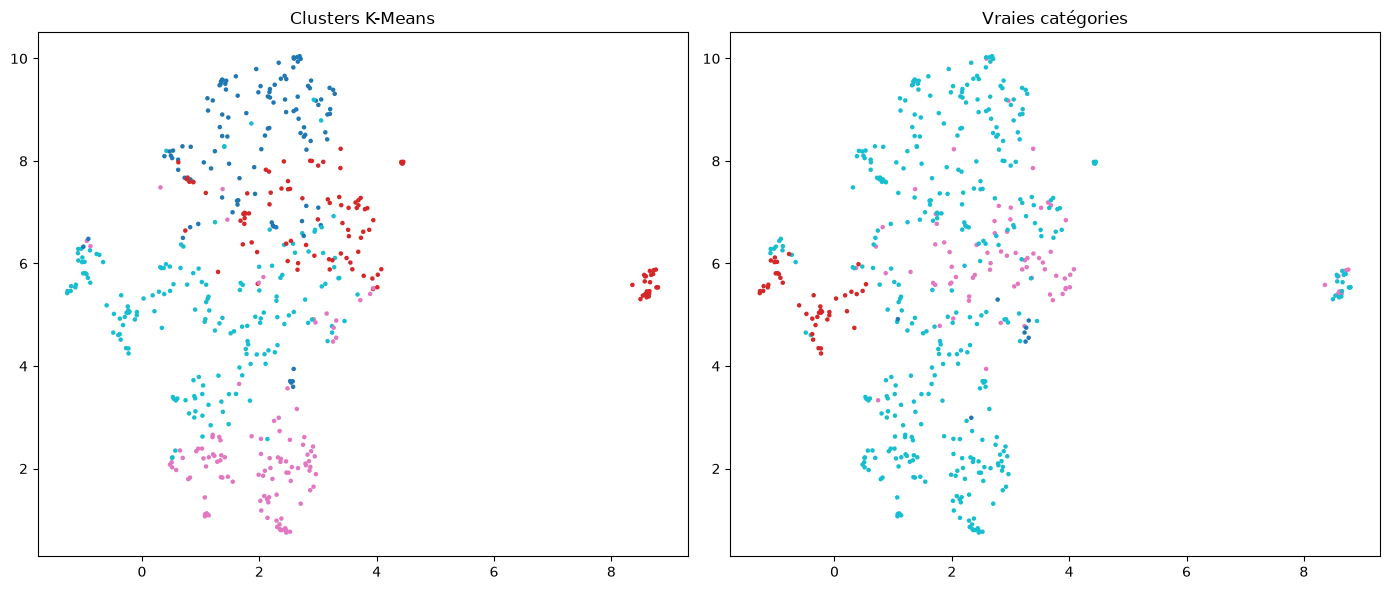

In [16]:
# ============================================
# TP8 - CLUSTERING DE DOCUMENTS
# ============================================

# 1. IMPORTS
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
import umap

# 2. CHARGER LE DATASET (avec le bon namespace)
from datasets import load_dataset
dataset = load_dataset("fancyzhx/ag_news", split="train[:500]")

texts = []
labels = []

for item in dataset:
    texts.append(item['text'])
    labels.append(item['label'])

categories = ['World', 'Sports', 'Business', 'Sci/Tech']
print(f"Nombre de documents : {len(texts)}")
print(f"Catégories : {categories}")

# 3. VECTORISER AVEC SENTENCE TRANSFORMERS
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Vectorisation...")
embeddings = model.encode(texts, show_progress_bar=True)
print(f"Embeddings shape : {embeddings.shape}")

# 4. NORMALISER + RÉDUIRE AVEC PCA
embeddings_norm = normalize(embeddings)
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings_norm)

# 5. K-MEANS
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings_pca)

# 6. ARI
ari = adjusted_rand_score(labels, clusters)
print(f"\n✅ ARI (Adjusted Rand Index) : {ari:.4f}")

# 7. RÉPARTITION PAR CLUSTER
for cluster_id in range(4):
    print(f"\n📌 Cluster {cluster_id} :")
    cluster_labels = [labels[i] for i in range(len(labels)) if clusters[i] == cluster_id]
    for cat_id, cat_name in enumerate(categories):
        count = cluster_labels.count(cat_id)
        print(f"  {cat_name}: {count}")

# 8. VISUALISATION UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=clusters, cmap='tab10', s=5)
axes[0].set_title('Clusters K-Means')
axes[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='tab10', s=5)
axes[1].set_title('Vraies catégories')
plt.tight_layout()
plt.show()

# 📋 RÉSUMÉ TP8 — Clustering de Documents

---

## 🧠 LA MENTALITÉ

> Le clustering permet de **regrouper automatiquement** des documents similaires sans connaître leurs catégories à l'avance. Sentence Transformers transforme chaque texte en vecteur sémantique, puis K-Means trouve des groupes.

---

## 🔄 LE PIPELINE

```
Texte brut → Sentence Transformer → Vecteur (384D)
                                         ↓
                                    PCA → 50D
                                         ↓
                                    K-Means → Clusters
                                         ↓
                                    ARI → Évaluation
```

---

## 💻 CHAQUE ÉTAPE

| Étape | Code | Rôle |
|-------|------|------|
| Vectorisation | `SentenceTransformer` | Transforme un texte en vecteur de 384 nombres |
| Normalisation | `normalize()` | Rend tous les vecteurs de longueur 1 |
| Réduction | `PCA(n=50)` | Réduit de 384D à 50D pour K-Means |
| Clustering | `KMeans(k=4)` | Trouve 4 groupes dans les données |
| Évaluation | `adjusted_rand_score` | Compare clusters vs vraies catégories |
| Visualisation | `UMAP` | Projette en 2D pour afficher |

---

## 📊 RÉSULTAT

- **ARI = 0.02** (faible)
- Cause : catégories déséquilibrées, titres sémantiquement proches
- **Le pipeline fonctionne**, même si le score est bas sur ce dataset

---

## ✅ CE QUE J'AI APPRIS

1. **Sentence Transformers** : embeddings de phrases prêts à l'emploi
2. **Normalisation** : améliore K-Means pour la similarité cosinus
3. **PCA** : réduit les dimensions avant clustering
4. **K-Means** : algorithme de clustering non supervisé
5. **ARI** : mesure la qualité d'un clustering (-1 à 1)
6. **UMAP** : visualisation 2D des clusters